In [3]:
import requests
import csv
import os
import random
import time
from datetime import datetime

# ==========================
# Configuration
# ==========================
API_KEY = "306536de5ff64818b4355111262107"
CSV_FILE = "weather_data.csv"

# List of 100 Indian Cities
cities = [
    "Mumbai","Delhi","Bengaluru","Hyderabad","Ahmedabad","Chennai",
    "Kolkata","Surat","Pune","Jaipur","Lucknow","Kanpur","Nagpur",
    "Indore","Thane","Bhopal","Visakhapatnam","Patna","Vadodara",
    "Ghaziabad","Ludhiana","Agra","Nashik","Faridabad","Meerut",
    "Rajkot","Kalyan","Vasai","Varanasi","Srinagar","Aurangabad",
    "Dhanbad","Amritsar","Navi Mumbai","Prayagraj","Ranchi","Howrah",
    "Coimbatore","Jabalpur","Gwalior","Vijayawada","Jodhpur",
    "Madurai","Raipur","Kota","Guwahati","Chandigarh","Solapur",
    "Hubli","Tiruchirappalli","Bareilly","Mysuru","Tiruppur",
    "Gurugram","Aligarh","Jalandhar","Bhubaneswar","Salem",
    "Warangal","Mira Bhayandar","Jalgaon","Guntur",
    "Thiruvananthapuram","Bhiwandi","Saharanpur","Gorakhpur",
    "Bikaner","Amravati","Noida","Jamshedpur","Bhilai",
    "Cuttack","Firozabad","Kochi","Nellore","Bhavnagar",
    "Dehradun","Durgapur","Asansol","Rourkela","Nanded",
    "Kolhapur","Ajmer","Akola","Kalaburagi","Jamnagar",
    "Ujjain","Loni","Siliguri","Jhansi","Ulhasnagar",
    "Jammu","Sangli","Mangalore","Erode","Belagavi",
    "Ambattur","Tirunelveli","Malegaon"
]

# Randomize city order
random.shuffle(cities)

# If you want exactly 100 cities
cities = cities[:100]

url = "http://api.weatherapi.com/v1/current.json"

# Create CSV if it doesn't exist
file_exists = os.path.isfile(CSV_FILE)

with open(CSV_FILE, "a", newline="", encoding="utf-8") as file:

    writer = csv.writer(file)

    if not file_exists:
        writer.writerow([
            "Timestamp",
            "City",
            "Country",
            "Temperature (°C)",
            "Feels Like (°C)",
            "Humidity (%)",
            "Pressure (mb)",
            "Wind Speed (km/h)",
            "Wind Direction",
            "Condition",
            "Cloud (%)",
            "Visibility (km)",
            "UV",
            "CO",
            "NO2",
            "O3",
            "PM2.5",
            "PM10"
        ])

    # Make API call for every city
    for i, city in enumerate(cities, start=1):

        print(f"({i}/100) Fetching weather for {city}...")

        params = {
            "key": API_KEY,
            "q": city,
            "aqi": "yes"
        }

        try:
            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()

            data = response.json()

            location = data["location"]["name"]
            country = data["location"]["country"]

            current = data["current"]

            air = current.get("air_quality", {})

            writer.writerow([
                datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                location,
                country,
                current["temp_c"],
                current["feelslike_c"],
                current["humidity"],
                current["pressure_mb"],
                current["wind_kph"],
                current["wind_dir"],
                current["condition"]["text"],
                current["cloud"],
                current["vis_km"],
                current["uv"],
                air.get("co", ""),
                air.get("no2", ""),
                air.get("o3", ""),
                air.get("pm2_5", ""),
                air.get("pm10", "")
            ])

            print(f"✓ Saved {location}")

        except requests.exceptions.HTTPError as e:
            print(f"✗ HTTP Error for {city}: {e}")

        except requests.exceptions.RequestException as e:
            print(f"✗ Network Error for {city}: {e}")

        except Exception as e:
            print(f"✗ Error for {city}: {e}")

        # Avoid hitting API rate limits
        time.sleep(1)

print("\nDone! Weather data for 100 Indian cities has been saved to weather_data.csv")

(1/100) Fetching weather for Jabalpur...
✓ Saved Jabalpur
(2/100) Fetching weather for Surat...
✓ Saved Surat
(3/100) Fetching weather for Ambattur...
✓ Saved Ambattur
(4/100) Fetching weather for Kochi...
✓ Saved Kochi
(5/100) Fetching weather for Guwahati...
✓ Saved Guwahati
(6/100) Fetching weather for Mumbai...
✓ Saved Mumbai
(7/100) Fetching weather for Amritsar...
✓ Saved Amritsar
(8/100) Fetching weather for Erode...
✓ Saved Erode
(9/100) Fetching weather for Thane...
✓ Saved Thanesar
(10/100) Fetching weather for Bikaner...
✓ Saved Bikaner
(11/100) Fetching weather for Ranchi...
✓ Saved Ranchi
(12/100) Fetching weather for Nanded...
✓ Saved Nanded
(13/100) Fetching weather for Kolkata...
✓ Saved Kolkata
(14/100) Fetching weather for Jamshedpur...
✓ Saved Jamshedpur
(15/100) Fetching weather for Jodhpur...
✓ Saved Jodhpur
(16/100) Fetching weather for Nellore...
✓ Saved Nellore
(17/100) Fetching weather for Thiruvananthapuram...
✓ Saved Thiruvananthapuram
(18/100) Fetching weath

In [4]:
import pandas as pd
df = pd.read_csv("weather_data.csv")
df.head()

,Timestamp,Location,Country,Temperature (°C),Feels Like,Humidity,Pressure,Wind Speed,Wind Direction,Condition,Cloud,Visibility,UV,CO,NO2,O3,PM2.5,PM10
0,2026-07-21 11:27:53,Jabalpur,India,28.2,34.0,84,1005.0,13.0,W,Mist,75,4.0,1.6,213.0,3.7,78.0,3.9,4.1
1,2026-07-21 15:58:24,Kolkata,India,30.3,37.8,79,1001.0,17.6,SSE,Mist,75,5.0,0.6,413.0,9.2,89.0,13.8,14.1
2,2026-07-21 15:58:26,Siliguri,Nepal,21.8,16.7,88,1005.0,5.8,SSW,Light rain shower,52,10.0,1.3,218.0,0.7,87.0,3.1,3.1
3,2026-07-21 15:58:27,Srinagar,India,23.9,18.7,73,1003.0,5.8,S,Light rain shower,62,10.0,2.7,654.0,7.5,93.0,7.3,7.5
4,2026-07-21 15:58:30,Thanesar,India,26.1,24.6,91,1001.0,13.7,ESE,Light rain,100,9.0,0.0,469.0,19.4,66.0,33.9,39.7


<Axes: xlabel='Temperature (°C)', ylabel='Feels Like'>

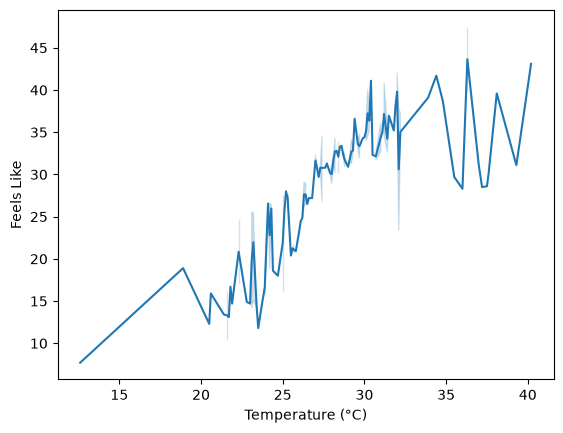

In [ ]:
import seaborn as sns

# Realtion between Temprature and Feels Like
sns.lineplot(
    df,
    x = "Temperature (°C)", y = "Feels Like"
)

<Axes: xlabel='Humidity', ylabel='Temperature (°C)'>

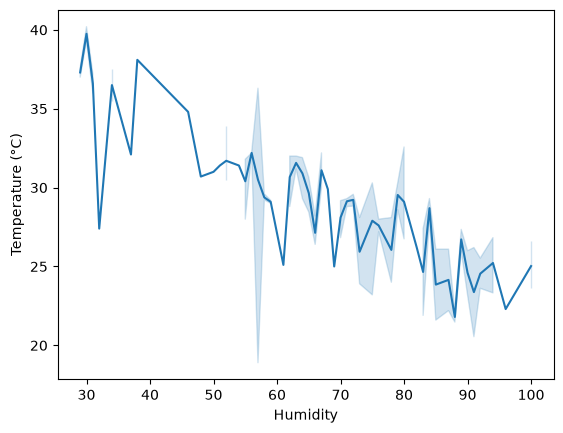

In [ ]:
# Realtion between Humidity and Temperature
sns.lineplot(
    df,
    x = "Humidity", y = "Temperature (°C)"
)

<Axes: xlabel='Temperature (°C)', ylabel='Pressure'>

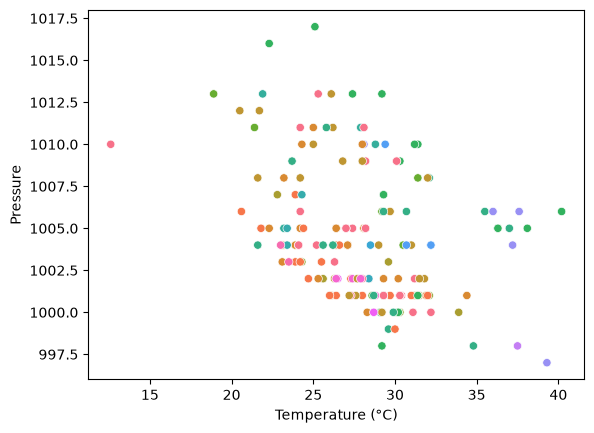

In [22]:
sns.scatterplot(
    df,
    x = "Temperature (°C)", y = "Pressure",
    hue = "Condition" , legend = None
)
